<a href="https://colab.research.google.com/github/bhargavanarasimhaai24/Statistical-Modelling/blob/main/Ridge_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BMI Index Prediction using Linear Regression and Ridge Regression

## Overview

This project explores the prediction of a numerical BMI-related `Index` using:

- Gender
- Height
- Weight

The analysis follows a model-selection approach:

1. Perform exploratory data analysis.
2. Train **Linear Regression** as the baseline model.
3. Analyze multicollinearity among the input features using **Variance Inflation Factor (VIF)**.
4. If substantial multicollinearity is detected, consider **Ridge Regression** as a regularized alternative.
5. Compare the models using appropriate regression metrics.
6. Analyze predictions and residuals.

The main objective is not only to build a regression model, but also to understand **when and why regularization such as Ridge Regression may be useful**.

## 1. Problem Statement

Given an individual's **Gender, Height, and Weight**, the objective is to predict the corresponding `Index`.

We begin with ordinary Linear Regression because it provides a simple and interpretable baseline.

However, when predictor variables are strongly related to each other, a problem called **multicollinearity** can make regression coefficients unstable.

Therefore, after fitting the baseline model, we investigate multicollinearity using **VIF**.

If the VIF analysis indicates substantial multicollinearity, Ridge Regression is considered because its L2 regularization can reduce the magnitude and instability of regression coefficients.

> **Note:** This notebook treats `Index` as a numerical regression target. This assumption should be verified against the meaning of the original dataset before using the model in a real application.

## 2. Import Libraries

The following libraries are used for data manipulation, visualization, statistical analysis, and machine learning.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 3. Load the Dataset

The dataset is loaded into a Pandas DataFrame.

We first inspect the first few records to understand the structure of the data.

In [33]:
df = pd.read_csv("bmi.csv")
df.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [34]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (500, 4)

Column names:
['Gender', 'Height', 'Weight', 'Index']

Data types:
Gender    object
Height     int64
Weight     int64
Index      int64
dtype: object


## 4. Understanding the Dataset

The main variables used in this project are:

| Feature | Description |
|---|---|
| `Gender` | Gender of the individual |
| `Height` | Height in centimeters |
| `Weight` | Weight in kilograms |
| `Index` | Numerical target to be predicted |

Before applying machine learning, the dataset should be checked for:

- Missing values
- Duplicate observations
- Unexpected categories
- Basic statistical properties

In [35]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values:")
print(df.nunique())

print("\nStatistical summary:")
display(df.describe())

Missing values:
Gender    0
Height    0
Weight    0
Index     0
dtype: int64

Duplicate rows: 11

Unique values:
Gender      2
Height     60
Weight    110
Index       6
dtype: int64

Statistical summary:


,Height,Weight,Index
count,500.0000,500.0000,500.0000
mean,169.9440,106.0000,3.7480
std,16.3753,32.3826,1.3551
min,140.0000,50.0000,0.0000
25%,156.0000,80.0000,3.0000
50%,170.5000,106.0000,4.0000
75%,184.0000,136.0000,5.0000
max,199.0000,160.0000,5.0000


### Initial Data Check

The dataset is inspected before preprocessing so that potential data-quality problems can be identified early.

Missing values may require imputation or removal, while duplicate observations should be examined to determine whether they are legitimate repeated records.

The numerical summary also provides an initial understanding of the scale and distribution of the variables.

## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed before model training to understand the relationships between the variables.

In particular, we investigate:

- Gender distribution
- Distribution of Height and Weight
- Relationship between Height and Weight
- Correlation among numerical features

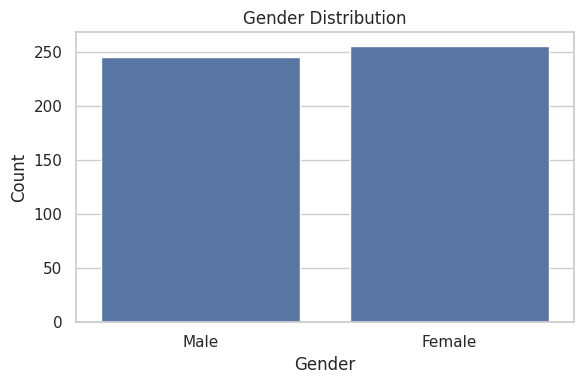

In [36]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

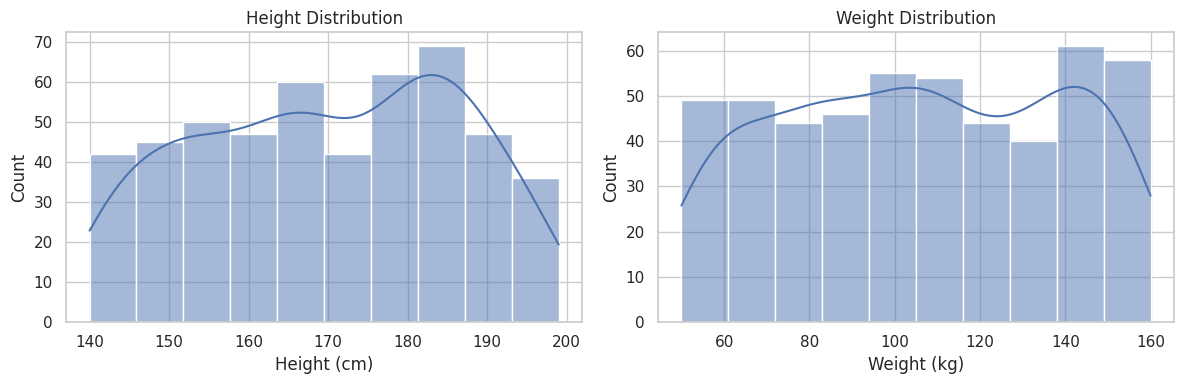

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Height"], kde=True, ax=axes[0])
axes[0].set_title("Height Distribution")
axes[0].set_xlabel("Height (cm)")

sns.histplot(df["Weight"], kde=True, ax=axes[1])
axes[1].set_title("Weight Distribution")
axes[1].set_xlabel("Weight (kg)")

plt.tight_layout()
plt.show()

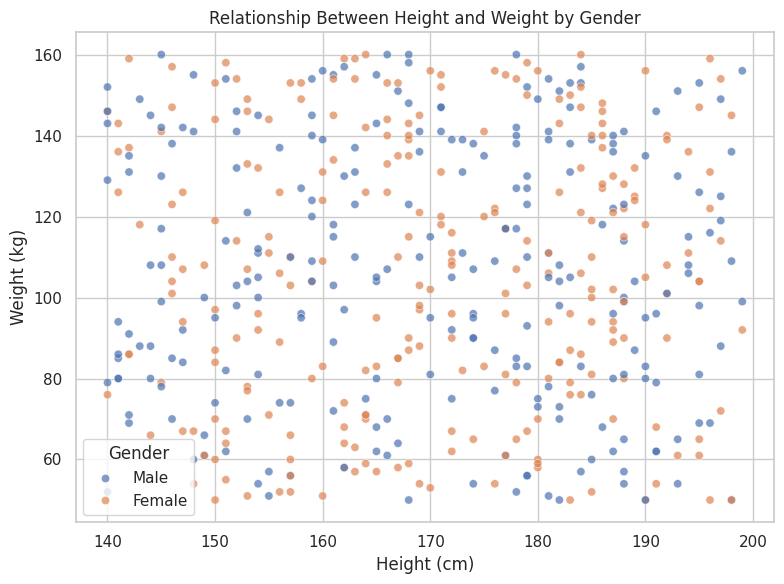

In [38]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Height",
    y="Weight",
    hue="Gender",
    alpha=0.7
)

plt.title("Relationship Between Height and Weight by Gender")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.tight_layout()
plt.show()

### Correlation Analysis

Correlation measures the strength and direction of a linear relationship between two numerical variables.

The Pearson correlation coefficient ranges from:

- **+1** → strong positive linear relationship
- **0** → little or no linear relationship
- **-1** → strong negative linear relationship

A strong relationship between two predictor variables can indicate possible **multicollinearity**.

However, correlation alone is not sufficient to decide whether multicollinearity is problematic. Therefore, VIF will be used later for a more direct diagnostic.

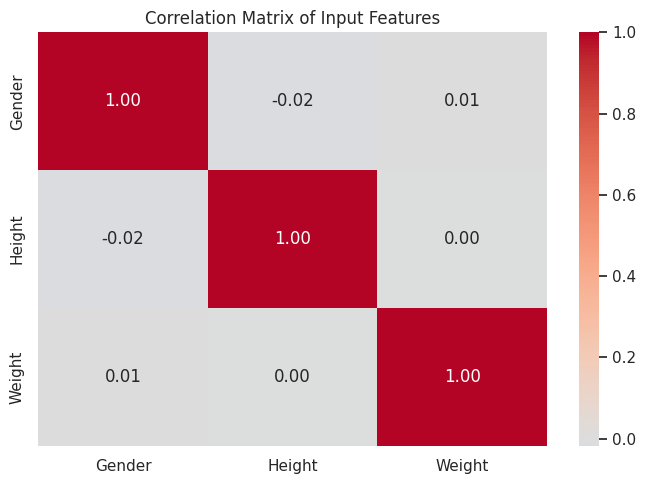

In [39]:
# Encode Gender temporarily for correlation analysis
df_corr = df.copy()

df_corr['Gender'] = df_corr['Gender'].map({'Male':1, "Female":0})

feature_columns = ["Gender", "Height", "Weight"]

correlation = df_corr[feature_columns].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.title("Correlation Matrix of Input Features")
plt.tight_layout()
plt.show()

## 6. Data Preprocessing

Machine learning models require numerical input features.

The `Gender` variable is categorical, so it is encoded as:

- Male → `1`
- Female → `0`

The target variable is `Index`.

The resulting feature matrix is:

$$
X = [Gender,\ Height,\ Weight]
$$

and the target vector is:

$$
y = Index
$$

In [40]:
df_model = df.copy()

df_model["Gender"] = df_model["Gender"].map({"Male": 1, "Female": 0})

X = df_model[["Gender", "Height", "Weight"]]
y = df_model["Index"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Feature matrix shape: (500, 3)
Target shape: (500,)


,Gender,Height,Weight
0,1,174,96
1,1,189,87
2,0,185,110
3,0,195,104
4,1,149,61


,Index
0,4
1,2
2,4
3,3
4,3


## 7. Train-Test Split

The data is divided into training and testing sets.

- **80%** of the data is used for training.
- **20%** is reserved for testing.

The model learns its parameters only from the training data.

The test set represents unseen observations and is used to evaluate how well the trained model generalizes.

A fixed `random_state=42` is used to make the experiment reproducible.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 8. Linear Regression — Baseline Model

Linear Regression is used as the baseline model.

The model assumes that the target can be approximated by a linear combination of the input features:

$$
\hat{y}
=
\beta_0
+
\beta_1X_1
+
\beta_2X_2
+
\beta_3X_3
$$

where:

- $\beta_0$ is the intercept.
- $\beta_1,\beta_2,\beta_3$ are the learned coefficients.
- $X_1,X_2,X_3$ represent Gender, Height, and Weight.
- $\hat{y}$ is the predicted value.

The coefficients provide an interpretable estimate of how each feature affects the prediction while the other features are held constant.

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

print(f"Intercept (β₀): {linear_model.intercept_:.4f}")

print("\nCoefficients:")
for feature, coefficient in zip(X.columns, linear_model.coef_):
    print(f"{feature:10s}: {coefficient:.4f}")

Intercept (β₀): 3.7375

Coefficients:
Gender    : 0.0324
Height    : -0.5943
Weight    : 1.1157


## 9. Evaluating the Linear Regression Model

Three metrics are used to evaluate the regression model.

### R² Score

R² measures the proportion of variance in the target that is explained by the model.

Higher values generally indicate better predictive performance.

### Mean Squared Error (MSE)

$$
MSE =
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

Because errors are squared, larger errors receive greater weight.

### Mean Absolute Error (MAE)

$$
MAE =
\frac{1}{n}
\sum_{i=1}^{n}
|y_i-\hat{y}_i|
$$

MAE represents the average absolute prediction error and is easier to interpret than MSE.

In [44]:
linear_r2 = r2_score(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_mae = mean_absolute_error(y_test, y_pred_linear)

print("Linear Regression Performance")
print("-" * 35)
print(f"R² Score : {linear_r2:.4f}")
print(f"MSE      : {linear_mse:.4f}")
print(f"MAE      : {linear_mae:.4f}")

Linear Regression Performance
-----------------------------------
R² Score : 0.7963
MSE      : 0.3394
MAE      : 0.4684


## 10. Why Check for Multicollinearity?

The Linear Regression model provides a baseline.

Before deciding whether regularization is necessary, we examine whether the predictor variables are strongly related to each other.

This is known as **multicollinearity**.

Multicollinearity can:

- Make regression coefficients unstable.
- Make coefficient interpretation difficult.
- Increase the variance of coefficient estimates.

The correlation matrix provided an initial visual indication of relationships between predictors.

To quantify multicollinearity more directly, we now calculate **Variance Inflation Factor (VIF)**.

### Variance Inflation Factor (VIF)

For a predictor $X_j$, VIF is defined as:

$$
VIF_j =
\frac{1}{1-R_j^2}
$$

where $R_j^2$ is obtained by regressing that predictor against all the other predictors.

A larger VIF means that the predictor can be explained more strongly by the remaining predictors.

A commonly used rule of thumb is:

| VIF | Interpretation |
|---:|---|
| ≈ 1 | Very little multicollinearity |
| 1–5 | Usually acceptable |
| > 5 | Potentially concerning |
| > 10 | Strong multicollinearity |

These are guidelines rather than strict mathematical cutoffs.

The VIF will be calculated using the **training data**, since model-related diagnostics should not depend on the held-out test set.

In [45]:
X_vif = X_train.copy()
X_vif_constant = sm.add_constant(X_vif)

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_constant.values,i + 1)for i in range(len(X_vif.columns))]

vif_data

,Feature,VIF
0,Gender,1.0020
1,Height,1.0019
2,Weight,1.0024


## 11. Deciding Whether Ridge Regression Is Needed

VIF is being used here as a **diagnostic step**, not as a reason to automatically apply Ridge.

The reasoning is:

$$
\text{Check multicollinearity}
\rightarrow
\text{Calculate VIF}
\rightarrow
\text{Assess severity}
\rightarrow
\text{Consider Ridge if necessary}
$$

A high VIF suggests that multicollinearity may be affecting the regression model.

Therefore, if any predictor has a substantially high VIF, Ridge Regression is a reasonable regularized alternative to investigate.

If the VIF values are low, ordinary Linear Regression may already be sufficient, and Ridge is not required specifically because of multicollinearity.

> **Important:** The presence of correlation by itself does not mean Ridge is mandatory. The concern is substantial multicollinearity.

In [46]:
VIF_THRESHOLD = 5

high_vif_features = vif_data[vif_data["VIF"] > VIF_THRESHOLD]["Feature"].tolist()

if high_vif_features:
    ridge_needed = True
    print("Potential multicollinearity detected.")
    print("Features with VIF > 5:", high_vif_features)
    print("\nRidge Regression will be investigated.")
else:
    ridge_needed = False
    print("No substantial multicollinearity detected using the chosen VIF threshold.")
    print("\nLinear Regression is sufficient from a multicollinearity perspective.")

No substantial multicollinearity detected using the chosen VIF threshold.

Linear Regression is sufficient from a multicollinearity perspective.


## 12. Ridge Regression as a Regularization Experiment

The VIF analysis did not identify substantial multicollinearity in the predictor variables. Therefore, Ridge Regression is **not required specifically to address multicollinearity** in this dataset.

However, Ridge Regression is also a general regularization technique that can reduce the magnitude of model coefficients and potentially improve generalization.

Therefore, Ridge Regression is investigated here as an **experimental comparison** with the Linear Regression baseline.

The objective is to determine whether L2 regularization provides any benefit even though strong multicollinearity was not detected.

> This distinction is important: VIF is used to diagnose multicollinearity, while Ridge is being explored here as a regularization technique rather than being applied because VIF was high.

In [47]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 3, 50)

ridge_model = RidgeCV(alphas=alphas, cv=5)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

print(f"Selected alpha: {ridge_model.alpha_:.6f}")

Selected alpha: 0.868511


In [48]:
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge Regression Performance")
print("-" * 35)
print(f"R² Score : {ridge_r2:.4f}")
print(f"MSE      : {ridge_mse:.4f}")
print(f"MAE      : {ridge_mae:.4f}")

Ridge Regression Performance
-----------------------------------
R² Score : 0.7968
MSE      : 0.3385
MAE      : 0.4682


In [49]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "R²": [linear_r2, ridge_r2],
    "MSE": [linear_mse, ridge_mse],
    "MAE": [linear_mae, ridge_mae]
})

comparison

,Model,R²,MSE,MAE
0,Linear Regression,0.7963,0.3394,0.4684
1,Ridge Regression,0.7968,0.3385,0.4682


## 13. Comparing Linear Regression and Ridge Regression

The two models are evaluated on the same unseen test set.

The results show that Ridge Regression achieves a slightly higher R² score and slightly lower MSE and MAE than Linear Regression.

However, the improvement is small.

This is important because Ridge was **not required to address substantial multicollinearity**, as the VIF analysis showed. Instead, this experiment shows that regularization can still provide a small improvement in generalization even when multicollinearity is not severe.

Therefore, model selection should be based on the observed results rather than assuming that Ridge will always outperform Linear Regression.

In [50]:
r2_improvement = ridge_r2 - linear_r2
mse_improvement = linear_mse - ridge_mse
mae_improvement = linear_mae - ridge_mae

r2_percentage = (r2_improvement / linear_r2) * 100
mse_percentage = (mse_improvement / linear_mse) * 100
mae_percentage = (mae_improvement / linear_mae) * 100

print("Improvement of Ridge over Linear Regression")
print("-" * 50)

print(f"R² improvement  : {r2_improvement:.6f} ({r2_percentage:.4f}%)")
print(f"MSE improvement : {mse_improvement:.6f} ({mse_percentage:.4f}%)")
print(f"MAE improvement : {mae_improvement:.6f} ({mae_percentage:.4f}%)")

Improvement of Ridge over Linear Regression
--------------------------------------------------
R² improvement  : 0.000527 (0.0662%)
MSE improvement : 0.000878 (0.2587%)
MAE improvement : 0.000264 (0.0563%)


## 14. Effect of Ridge Regularization on Coefficients

Ridge Regression adds an L2 penalty that discourages large coefficient values.

Therefore, one of the main effects of Ridge is **coefficient shrinkage**.

The coefficients of Linear Regression and Ridge are compared below.

> Note: Ridge was trained using standardized features, so the magnitude of the Ridge coefficients is expressed with respect to the scaled features.

In [51]:
coefficient_comparison = pd.DataFrame({
    "Feature": X.columns,
    "Linear Regression": linear_model.coef_,
    "Ridge Regression": ridge_model.coef_
})

coefficient_comparison

,Feature,Linear Regression,Ridge Regression
0,Gender,0.0324,0.0325
1,Height,-0.5943,-0.5929
2,Weight,1.1157,1.1132


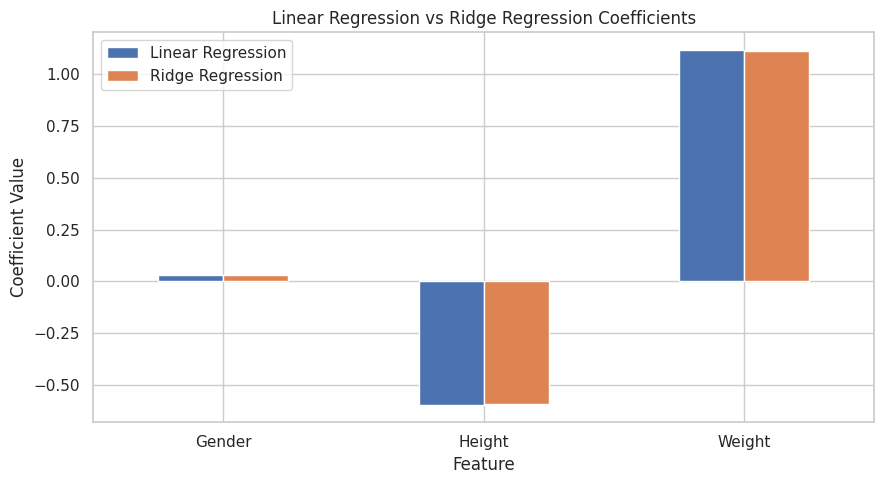

In [52]:
ax = coefficient_comparison.plot(x="Feature",y=["Linear Regression", "Ridge Regression"],kind="bar",figsize=(9, 5))

ax.set_title("Linear Regression vs Ridge Regression Coefficients")
ax.set_xlabel("Feature")
ax.set_ylabel("Coefficient Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. Interpretation of Results

The comparison shows that Ridge Regression performs slightly better than the baseline Linear Regression model on the test set.

| Model | R² | MSE | MAE |
|---|---:|---:|---:|
| Linear Regression | 0.7963 | 0.3394 | 0.4684 |
| Ridge Regression | 0.7968 | 0.3385 | 0.4682 |

Ridge Regression achieves:

- A slightly higher R² score.
- A slightly lower MSE.
- A slightly lower MAE.

However, the improvement is very small.

This is an important observation because the VIF analysis did **not** indicate substantial multicollinearity. Therefore, Ridge was not introduced because multicollinearity required it; instead, it was evaluated as a regularization technique to determine whether it could provide any improvement in predictive performance.

For this dataset, Ridge provides a small improvement over the Linear Regression baseline.

# 15. Conclusion

This notebook investigated the prediction of the `Index` using Linear Regression and Ridge Regression.

The workflow was:

**EDA → Preprocessing → Linear Regression → VIF Analysis → Ridge Regression → Model Comparison**

### Key Findings

1. **Linear Regression** was established as the baseline model.
2. Correlation analysis was used to understand relationships between the predictor variables.
3. **VIF** was used to diagnose multicollinearity.
4. The VIF values did not indicate substantial multicollinearity.
5. Therefore, Ridge Regression was not required specifically as a solution to multicollinearity.
6. Nevertheless, Ridge Regression was tested as a regularization technique.
7. Ridge produced a small improvement in all three evaluation metrics on the test set.

### Final Result

Ridge Regression achieved an R² of approximately **0.7968**, compared with **0.7963** for Linear Regression.

The improvement is modest, so Ridge cannot be considered dramatically better for this dataset. The experiment instead demonstrates an important machine learning principle:

> **Modeling decisions should be supported by data analysis and empirical evaluation rather than assumptions.**

VIF helps diagnose multicollinearity, while Ridge provides regularization. These are related concepts, but they serve different purposes.